In [113]:
1 + 1

2

In [128]:

from typing import Annotated
from typing_extensions import TypedDict 
from langgraph. graph import END, START 
from langgraph.graph.state import StateGraph 
from langgraph.graph.message import add_messages 
from langgraph. prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage 
import os
from dotenv import load_dotenv
load_dotenv()

True

In [129]:
# os.environ["LANGCHAIN_TRACING_V2"] = "true"

# # Pull your API key (ensure LANGSMITH_API_KEY is set in your environment/terminal)
# api_key = os.getenv("LANGSMITH_API_KEY")
# os.environ["LANGCHAIN_API_KEY"] = api_key
# os.environ["LANGSMITH_API_KEY"] = api_key

# os.environ["LANGCHAIN_PROJECT"] = "langgraph-learning"
# os.environ["LANGSMITH_PROJECT"] = "langgraph-learning"

# # SET MATCHING ENDPOINTS (Choose ONLY ONE pair based on where your account actually lives):

# # OPTION A: If your LangSmith account is in the EU region:
# os.environ["LANGCHAIN_ENDPOINT"] = "https://eu.api.smith.langchain.com"
# os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"

# # OPTION B: If your LangSmith account is on the default US region:
# # (Comment out Option A and uncomment these if your account was created on standard smith.langchain.com)
# # os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
# # os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

api_key = os.getenv("LANGSMITH_API_KEY")

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] ="https://eu.api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = api_key
os.environ["LANGSMITH_PROJECT"] ="langgraph-learning"


#from langgraph.graph import StateGraph, END

In [130]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(
    "groq:openai/gpt-oss-20b",
    temperature=0
)

print(llm)

metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}} profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True} client=<groq.resources.chat.completions.Completions object at 0x0000021C611A6000> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021C611A64E0> model_name='openai/gpt-oss-20b' temperature=1e-08 model_kwargs={} groq_api_key=SecretStr('**********')


In [131]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [132]:
from langchain_core.tools import tool

@tool
def add(a:float,b:float):
    """Add two numbers"""
    return a + b
tools =[add]
tool_node = ToolNode([add])

# Bind the tools to your LLM (using bind_tools is standard for modern chat models)
llm_with_tool = llm.bind_tools([add])

def call_llm_model(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

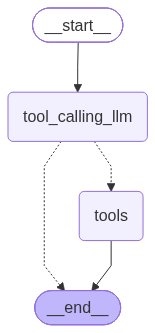

In [133]:

## Stategraph
from langgraph.graph import StateGraph, START, END 
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
## Node definition
def call_llm_model(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
## Grpah
builder = StateGraph (State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools", ToolNode(tools))
## Add Edges
builder.add_edge (START, "tool_calling_llm")
builder.add_conditional_edges ( "tool_calling_llm",tools_condition)
builder.add_edge("tools",END)

graph = builder.compile()

from IPython.display import Image,  display
display(Image(graph.get_graph().draw_mermaid_png()))

In [134]:
response = graph.invoke({"messages":"What is the capital of India?"})

In [135]:
print(response)

{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='ab7e09b3-ea3d-4212-8505-0c2366ac781b'), AIMessage(content='The capital of India is **New\u202fDelhi**.', additional_kwargs={'reasoning_content': 'User asks: "What is the capital of India?" Simple factual question. Answer: New Delhi.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 127, 'total_tokens': 168, 'completion_time': 0.045564186, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.010840718, 'prompt_tokens_details': None, 'queue_time': 0.003107152, 'total_time': 0.056404904}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0bf67-35c6-70e1-b095-28f409ba102c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 127, 'output_tokens': 41, 'total_tokens': 168, 